In [ ]:
from google.colab import drive
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/GDP_NTL_Project"
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "gdp_ntl_panel_2012_2025.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

dataset = pd.read_csv(DATA_PATH)

print("Розмір набору даних:", dataset.shape)
print(
    "Кількість країн:",
    dataset["CNTR_ID"].nunique()
)
print(
    "Період:",
    dataset["year"].min(),
    "—",
    dataset["year"].max()
)

display(dataset.head())

Mounted at /content/drive
Розмір набору даних: (504, 37)
Кількість країн: 36
Період: 2012 — 2025


,CNTR_ID,NAME_ENGL,year,country_area_km2,n_valid_pixels,valid_ntl_area_km2,ntl_mean,ntl_median,ntl_std,ntl_p25,...,water_share,qa0_share,qa1_share,qa2_share,invalid_radiance_share,valid_ntl_area_km2_qa01,ntl_mean_area_weighted_qa01,ntl_sum_area_weighted_qa01,ntl_coverage_share_qa01,gdp_meur
0,AL,Albania,2012,28806.031029,175875,28468.848979,0.478369,0.0,3.670705,0.0,...,0.011514,0.988295,0.000163,0.000000,0.0,28473.541699,0.478058,13612.009732,0.988458,9578.6
1,AL,Albania,2013,28806.031029,175872,28468.358826,0.473239,0.0,3.716385,0.0,...,0.011536,0.988278,0.000158,0.000000,0.0,28472.899331,0.472847,13463.311158,0.988435,9669.8
2,AL,Albania,2014,28806.031029,175869,28467.871955,0.448598,0.0,3.542073,0.0,...,0.011598,0.988261,0.000113,0.000000,0.0,28471.125460,0.448293,12763.419815,0.988374,10018.0
3,AL,Albania,2015,28806.031029,175879,28469.475546,0.423677,0.0,3.616563,0.0,...,0.011553,0.988316,0.000102,0.000000,0.0,28472.418578,0.423596,12060.788738,0.988419,10371.5
4,AL,Albania,2016,28806.031029,175891,28471.414757,0.406204,0.0,3.802593,0.0,...,0.011474,0.988384,0.000108,0.000006,0.0,28474.518672,0.406305,11569.331486,0.988492,10922.7


In [ ]:
# Сортування повної панелі
dataset = (
    dataset
    .sort_values(["CNTR_ID", "year"])
    .reset_index(drop=True)
)

# Логарифм сумарного показника NTL
dataset["log_ntl_sum"] = np.log(
    dataset["ntl_sum_area_weighted"]
)

# Річна логарифмічна зміна сумарного NTL
dataset["ntl_sum_log_change"] = (
    dataset
    .groupby("CNTR_ID")["log_ntl_sum"]
    .diff()
)

# Формування модельної вибірки
model_data = (
    dataset
    .dropna(subset=["gdp_meur"])
    .copy()
    .reset_index(drop=True)
)

print(
    "Кількість спостережень у модельній вибірці:",
    len(model_data)
)

print(
    "Кількість країн:",
    model_data["CNTR_ID"].nunique()
)

print(
    "Кількість пропущених значень ВВП:",
    model_data["gdp_meur"].isna().sum()
)

print(
    "Кількість пропущених значень NTL (QA0):",
    model_data["ntl_sum_area_weighted"].isna().sum()
)

print(
    "Кількість пропущених значень NTL (QA0+1):",
    model_data["ntl_sum_area_weighted_qa01"].isna().sum()
)

print(
    "Кількість пропусків у річній зміні NTL:",
    model_data["ntl_sum_log_change"].isna().sum()
)

Кількість спостережень у модельній вибірці: 502
Кількість країн: 36
Кількість пропущених значень ВВП: 0
Кількість пропущених значень NTL (QA0): 0
Кількість пропущених значень NTL (QA0+1): 0
Кількість пропусків у річній зміні NTL: 35


In [ ]:
variables = [
    "gdp_meur",
    "ntl_sum_area_weighted",
    "ntl_mean_area_weighted",
    "ntl_sum_area_weighted_qa01",
    "ntl_mean_area_weighted_qa01"
]

descriptive_stats = (
    model_data[variables]
    .describe()
    .T
)

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
gdp_meur,502.0,432381.481873,751364.542469,3169.300000,32322.650000,160379.500000,442767.550000,4.529710e+06
ntl_sum_area_weighted,502.0,142825.205577,210000.705675,248.300561,19405.237834,52186.095742,171549.588069,9.925438e+05
ntl_mean_area_weighted,502.0,1.712779,2.869235,0.144834,0.533751,0.819970,1.362696,1.956362e+01
ntl_sum_area_weighted_qa01,502.0,144622.309231,210988.537917,248.300561,19455.921177,53011.034290,176308.531171,9.926686e+05
ntl_mean_area_weighted_qa01,502.0,1.681322,2.830000,0.145219,0.521983,0.800029,1.361771,1.951111e+01


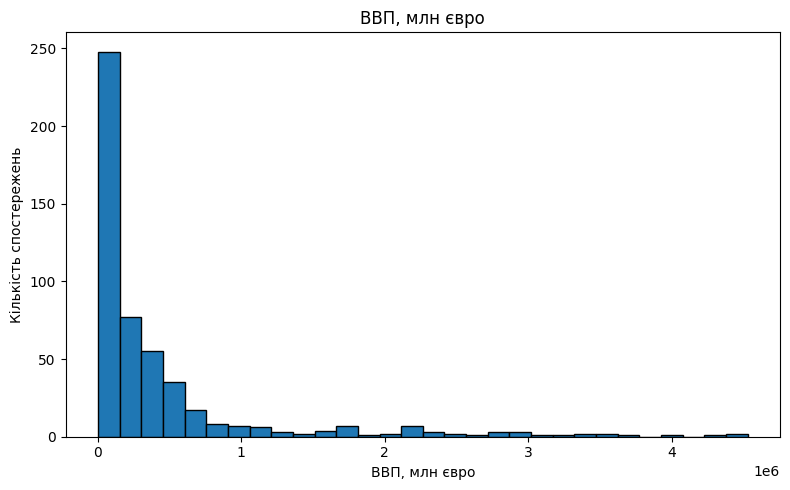

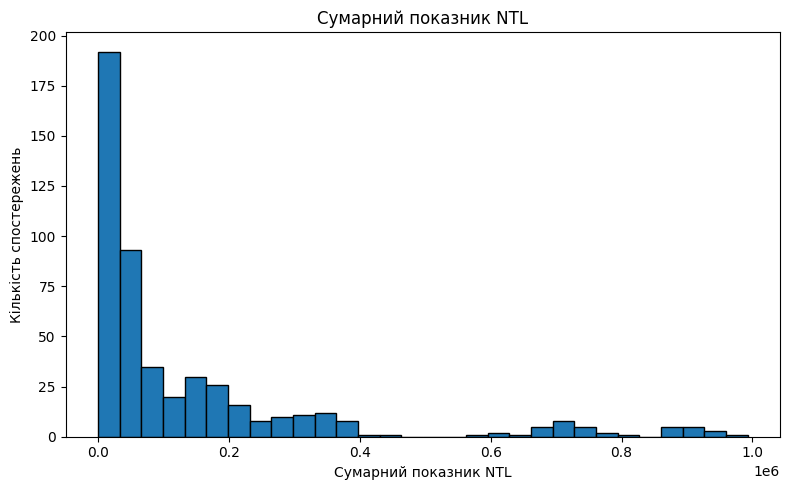

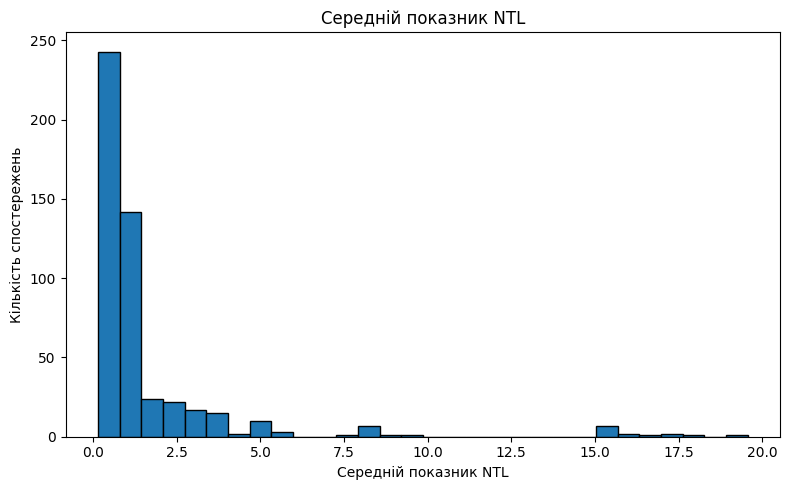

In [ ]:
hist_variables = {
    "gdp_meur": "ВВП, млн євро",
    "ntl_sum_area_weighted": "Сумарний показник NTL",
    "ntl_mean_area_weighted": "Середній показник NTL"
}

for variable, title in hist_variables.items():

    plt.figure(figsize=(8, 5))

    plt.hist(
        model_data[variable],
        bins=30,
        edgecolor="black"
    )

    plt.title(title)
    plt.xlabel(title)
    plt.ylabel("Кількість спостережень")

    plt.tight_layout()
    plt.show()

In [ ]:
model_data["log_gdp"] = np.log(
    model_data["gdp_meur"]
)

model_data["log_ntl_mean"] = np.log(
    model_data["ntl_mean_area_weighted"]
)

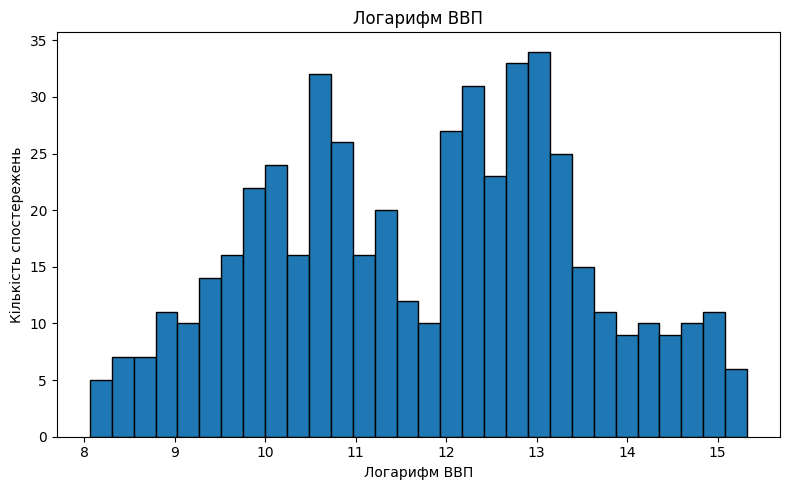

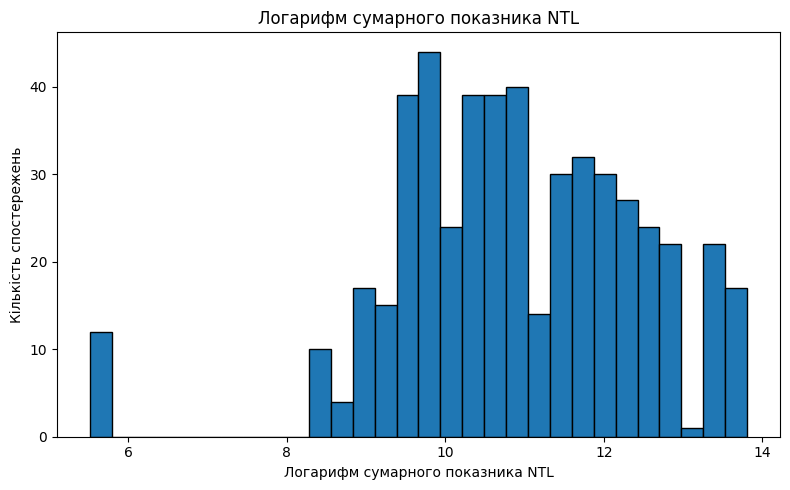

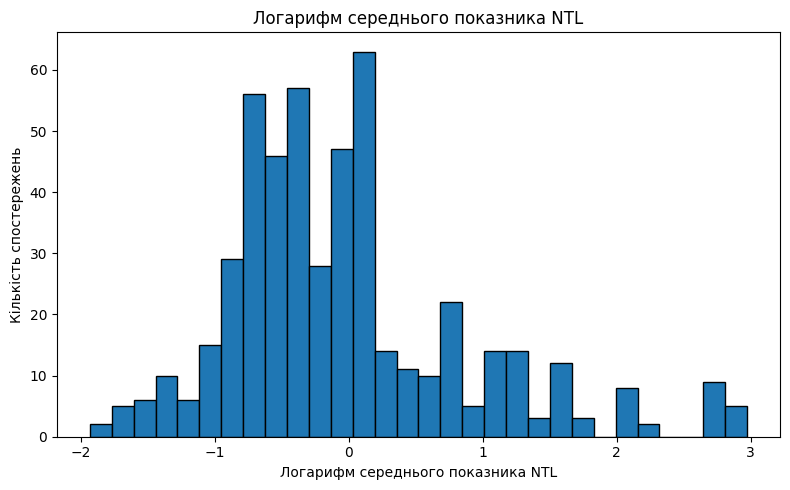

In [ ]:
log_variables = {
    "log_gdp": "Логарифм ВВП",
    "log_ntl_sum": "Логарифм сумарного показника NTL",
    "log_ntl_mean": "Логарифм середнього показника NTL"
}

for variable, title in log_variables.items():

    plt.figure(figsize=(8, 5))

    plt.hist(
        model_data[variable],
        bins=30,
        edgecolor="black"
    )

    plt.title(title)
    plt.xlabel(title)
    plt.ylabel("Кількість спостережень")

    plt.tight_layout()
    plt.show()

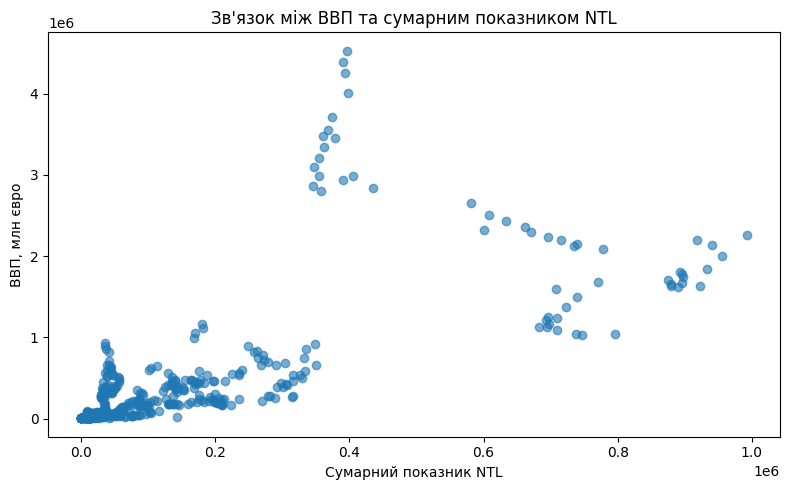

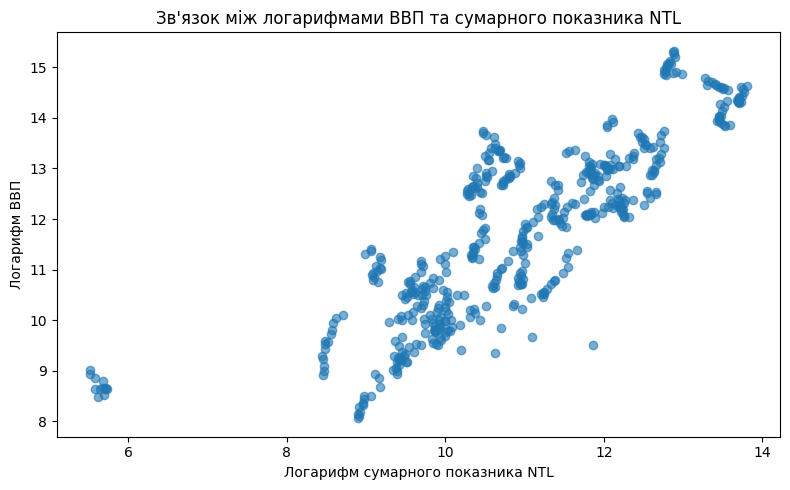

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data["ntl_sum_area_weighted"],
    model_data["gdp_meur"],
    alpha=0.6
)

plt.xlabel("Сумарний показник NTL")
plt.ylabel("ВВП, млн євро")
plt.title("Зв'язок між ВВП та сумарним показником NTL")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.scatter(
    model_data["log_ntl_sum"],
    model_data["log_gdp"],
    alpha=0.6
)

plt.xlabel("Логарифм сумарного показника NTL")
plt.ylabel("Логарифм ВВП")
plt.title("Зв'язок між логарифмами ВВП та сумарного показника NTL")

plt.tight_layout()
plt.show()

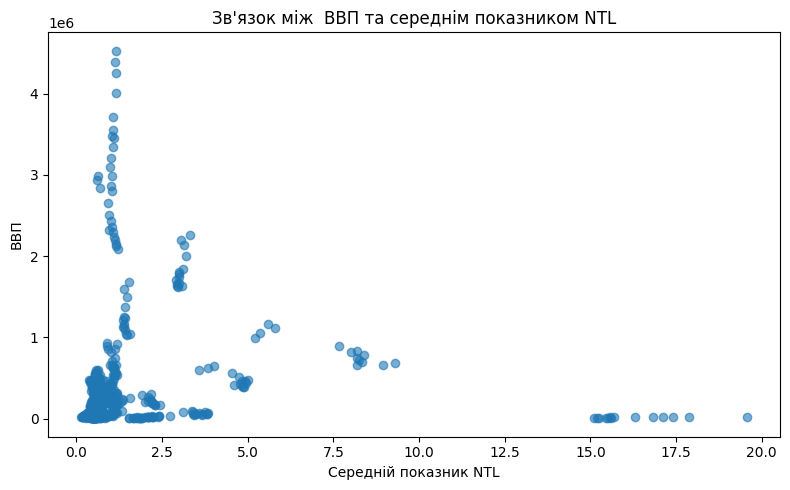

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data["ntl_mean_area_weighted"],
    model_data["gdp_meur"],
    alpha=0.6
)

plt.xlabel("Середній показник NTL")
plt.ylabel("ВВП")
plt.title("Зв'язок між  ВВП та середнім показником NTL")

plt.tight_layout()
plt.show()


In [ ]:
correlations = model_data[
    [
        "log_gdp",
        "log_ntl_sum",
        "log_ntl_mean"
    ]
].corr()

display(correlations)

,log_gdp,log_ntl_sum,log_ntl_mean
log_gdp,1.000000,0.832882,0.183838
log_ntl_sum,0.832882,1.000000,0.093501
log_ntl_mean,0.183838,0.093501,1.000000


In [ ]:
engineered_features = [
    "ntl_sum_area_weighted",
    "ntl_mean",
    "ntl_mean_area_weighted",
    "ntl_median",
    "ntl_std",
    "ntl_p25",
    "ntl_p75",
    "ntl_p90",
    "ntl_p95",
    "ntl_iqr",
    "ntl_cv",
    "lit_area_km2",
    "lit_area_share_valid",
    "ntl_positive_mean",
    "ntl_sum_log_change",
]

feature_summary = model_data[
    engineered_features
].describe().T

feature_summary["missing"] = (
    model_data[engineered_features]
    .isna()
    .sum()
)

feature_summary["zeros"] = (
    model_data[engineered_features]
    .eq(0)
    .sum()
)

display(feature_summary)

,count,mean,std,min,25%,50%,75%,max,missing,zeros
ntl_sum_area_weighted,502.0,142825.205577,210000.705675,248.300561,19405.237834,52186.095742,171549.588069,992543.762285,0,0
ntl_mean,502.0,1.712008,2.867356,0.142019,0.532047,0.815768,1.357034,19.557470,0,0
ntl_mean_area_weighted,502.0,1.712779,2.869235,0.144834,0.533751,0.819970,1.362696,19.563618,0,0
ntl_median,502.0,0.356198,1.410439,0.000000,0.000000,0.000000,0.000000,9.943402,0,417
ntl_std,502.0,10.147449,19.423777,2.285442,3.747406,5.130525,8.503612,160.614304,0,0
ntl_p25,502.0,0.111164,0.522370,0.000000,0.000000,0.000000,0.000000,3.758507,0,466
ntl_p75,502.0,1.201730,3.773981,0.000000,0.000000,0.000000,0.670853,25.434660,0,281
ntl_p90,502.0,3.454565,7.427285,0.000000,0.664429,1.128894,2.152801,51.065498,0,47
ntl_p95,502.0,6.253261,9.880164,0.000000,1.250815,3.240396,5.358537,67.426582,0,23
ntl_iqr,502.0,1.090566,3.264772,0.000000,0.000000,0.000000,0.661718,21.676153,0,281


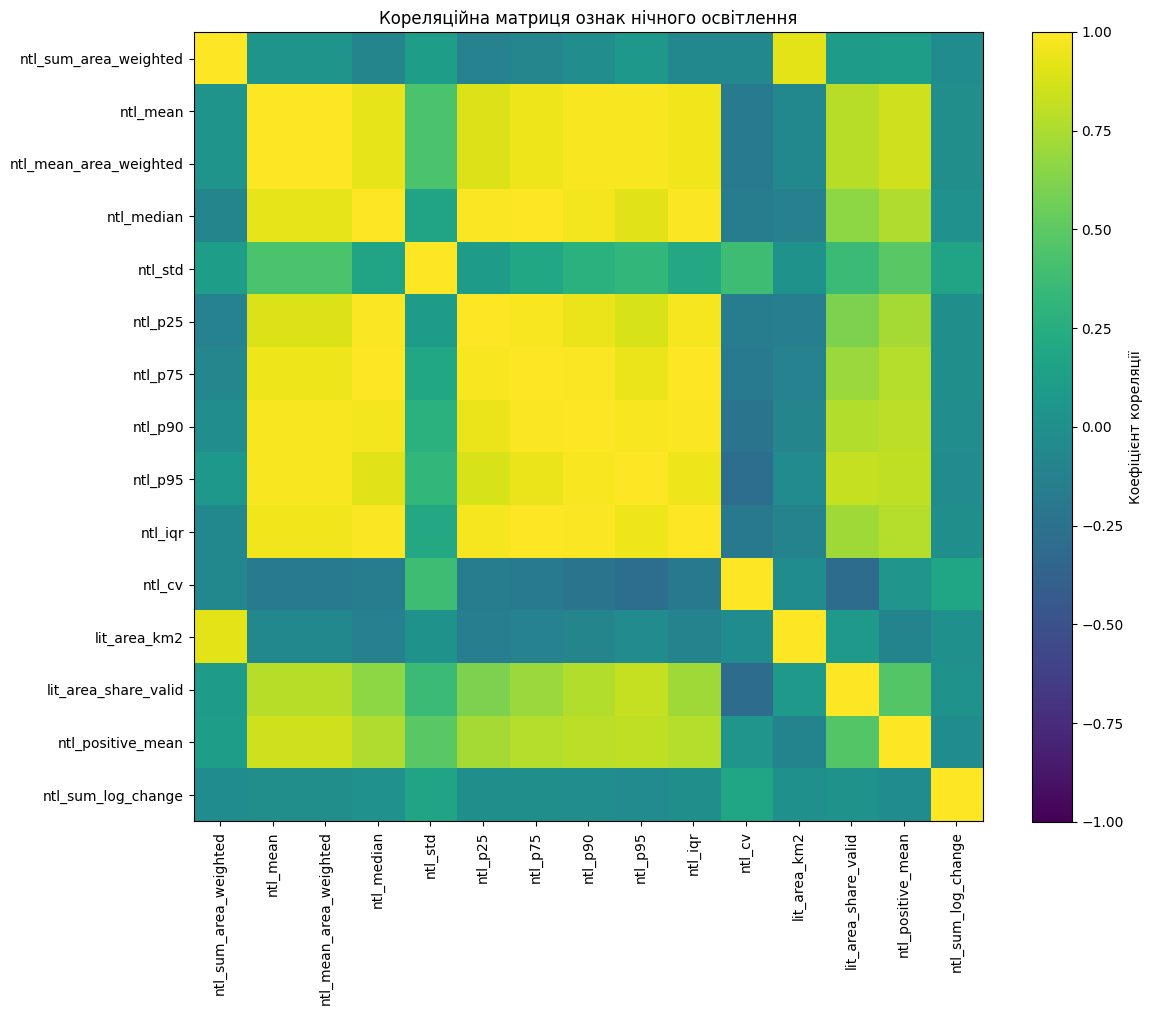

In [ ]:
feature_corr = (
    model_data[engineered_features]
    .corr()
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    feature_corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(engineered_features))
)
ax.set_yticks(
    range(len(engineered_features))
)

ax.set_xticklabels(
    engineered_features,
    rotation=90
)
ax.set_yticklabels(
    engineered_features
)

fig.colorbar(
    im,
    ax=ax,
    label="Коефіцієнт кореляції"
)

ax.set_title(
    "Кореляційна матриця ознак нічного освітлення"
)

plt.tight_layout()
plt.show()

In [ ]:
# Верхній трикутник кореляційної матриці
upper_triangle = np.triu(
    np.ones(feature_corr.shape),
    k=1
).astype(bool)

corr_pairs = (
    feature_corr
    .where(upper_triangle)
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

corr_pairs["abs_correlation"] = (
    corr_pairs["correlation"].abs()
)

strong_corr = (
    corr_pairs[
        corr_pairs["abs_correlation"] >= 0.80
    ]
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(strong_corr)

,feature_1,feature_2,correlation,abs_correlation
0,ntl_mean,ntl_mean_area_weighted,0.999989,0.999989
1,ntl_p75,ntl_iqr,0.999449,0.999449
2,ntl_median,ntl_p75,0.992907,0.992907
3,ntl_median,ntl_iqr,0.989885,0.989885
4,ntl_p90,ntl_iqr,0.987450,0.987450
5,ntl_median,ntl_p25,0.986785,0.986785
6,ntl_p75,ntl_p90,0.984569,0.984569
7,ntl_p90,ntl_p95,0.983443,0.983443
8,ntl_mean,ntl_p90,0.982474,0.982474
9,ntl_mean_area_weighted,ntl_p90,0.982168,0.982168


## Відбір ознак і підготовка даних до моделювання

Кореляційна матриця вище використовується для описового аналізу всієї вибірки. Фактичний відбір ознак для моделювання виконується **лише на навчальній вибірці**, щоб уникнути витоку інформації з тестового періоду.


In [ ]:
TRAIN_END_YEAR = 2021
TEST_START_YEAR = 2022

train_data = model_data[model_data["year"] <= TRAIN_END_YEAR].copy()
test_data = model_data[model_data["year"] >= TEST_START_YEAR].copy()

print("Навчальна вибірка:", len(train_data), "спостережень")
print("Період train:", train_data["year"].min(), "—", train_data["year"].max())
print("Тестова вибірка:", len(test_data), "спостережень")
print("Період test:", test_data["year"].min(), "—", test_data["year"].max())
print("Країн у train:", train_data["CNTR_ID"].nunique())
print("Країн у test:", test_data["CNTR_ID"].nunique())


Навчальна вибірка: 359 спостережень
Період train: 2012 — 2021
Тестова вибірка: 143 спостережень
Період test: 2022 — 2025
Країн у train: 36
Країн у test: 36


### Усунення сильно корельованих ознак

Із набору кандидатів послідовно вилучається одна ознака з пари, для якої абсолютна кореляція перевищує 0,80. Вилучається та ознака, що має вищу середню абсолютну кореляцію з рештою поточного набору.


In [ ]:
CORR_THRESHOLD = 0.80

# ntl_sum_log_change не включається до PCA через пропуски для першого року кожної країни
candidate_features = [
    "ntl_sum_area_weighted",
    "ntl_mean",
    "ntl_mean_area_weighted",
    "ntl_median",
    "ntl_std",
    "ntl_p25",
    "ntl_p75",
    "ntl_p90",
    "ntl_p95",
    "ntl_iqr",
    "ntl_cv",
    "lit_area_km2",
    "lit_area_share_valid",
    "ntl_positive_mean",
]

def select_features_by_correlation(data, features, threshold=0.80):
    selected = features.copy()
    history = []

    while len(selected) > 1:
        corr = data[selected].corr().abs()
        upper = corr.where(
            np.triu(np.ones(corr.shape), k=1).astype(bool)
        )
        max_corr = upper.max().max()

        if pd.isna(max_corr) or max_corr <= threshold:
            break

        feature_1, feature_2 = upper.stack().idxmax()
        mean_corr_1 = corr[feature_1].drop(feature_1).mean()
        mean_corr_2 = corr[feature_2].drop(feature_2).mean()

        if mean_corr_1 >= mean_corr_2:
            removed, paired = feature_1, feature_2
        else:
            removed, paired = feature_2, feature_1

        history.append({
            "removed_feature": removed,
            "paired_with": paired,
            "abs_correlation": max_corr,
        })
        selected.remove(removed)

    return selected, pd.DataFrame(history)

selected_features, correlation_filter_history = select_features_by_correlation(
    train_data,
    candidate_features,
    threshold=CORR_THRESHOLD,
)

print("Вилучені ознаки:")
display(correlation_filter_history)

print("Ознаки, що залишилися для PCA:")
print(selected_features)


Вилучені ознаки:


,removed_feature,paired_with,abs_correlation
0,ntl_mean,ntl_mean_area_weighted,0.999988
1,ntl_iqr,ntl_p75,0.999479
2,ntl_p75,ntl_median,0.992768
3,ntl_median,ntl_p25,0.988541
4,ntl_p95,ntl_p90,0.980750
5,ntl_mean_area_weighted,ntl_p90,0.975125
6,ntl_sum_area_weighted,lit_area_km2,0.937460
7,ntl_p90,ntl_p25,0.933531


Ознаки, що залишилися для PCA:
['ntl_std', 'ntl_p25', 'ntl_cv', 'lit_area_km2', 'lit_area_share_valid', 'ntl_positive_mean']


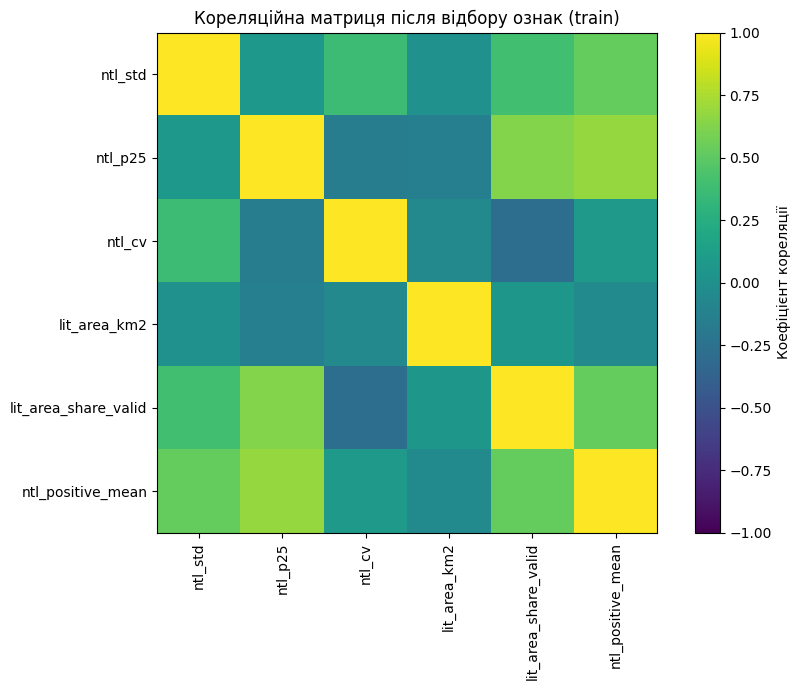

Максимальна абсолютна кореляція після відбору: 0.6819


In [ ]:
selected_corr = train_data[selected_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(selected_corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(selected_features)))
ax.set_yticks(range(len(selected_features)))
ax.set_xticklabels(selected_features, rotation=90)
ax.set_yticklabels(selected_features)
fig.colorbar(im, ax=ax, label="Коефіцієнт кореляції")
ax.set_title("Кореляційна матриця після відбору ознак (train)")
plt.tight_layout()
plt.show()

mask = ~np.eye(len(selected_corr), dtype=bool)
max_remaining_corr = selected_corr.abs().where(mask).max().max()
print("Максимальна абсолютна кореляція після відбору:", round(max_remaining_corr, 4))


### Логарифмування та PCA

PCA будується тільки на ознаках, що залишилися після кореляційного відбору. Перетворення `log1p`, стандартизація та PCA навчаються на train; до test застосовуються вже навчені перетворення.


In [ ]:
skewness_comparison = pd.DataFrame({
    "до log1p": train_data[selected_features].skew(),
    "після log1p": np.log1p(train_data[selected_features]).skew(),
})

display(skewness_comparison.sort_values("до log1p", ascending=False))


,до log1p,після log1p
ntl_p25,5.385274,4.831361
ntl_std,5.117774,2.193121
ntl_cv,3.506051,0.842929
ntl_positive_mean,2.410988,0.678973
lit_area_km2,1.836159,-0.760979
lit_area_share_valid,1.594174,1.290893


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

y_train = train_data["log_gdp"].copy()
y_test = test_data["log_gdp"].copy()

# Baseline: традиційний Sum of Lights
X_train_baseline = train_data[["log_ntl_sum"]].copy()
X_test_baseline = test_data[["log_ntl_sum"]].copy()

# Відібрані NTL-ознаки
X_train_engineered = np.log1p(train_data[selected_features]).copy()
X_test_engineered = np.log1p(test_data[selected_features]).copy()

# Стандартизація лише за train
pca_scaler = StandardScaler()
X_train_scaled = pca_scaler.fit_transform(X_train_engineered)
X_test_scaled = pca_scaler.transform(X_test_engineered)

# Мінімальна кількість компонент, що пояснює щонайменше 90% дисперсії train
pca_model = PCA(n_components=0.90)
X_train_pca_array = pca_model.fit_transform(X_train_scaled)
X_test_pca_array = pca_model.transform(X_test_scaled)

pca_columns = [f"PC{i}" for i in range(1, pca_model.n_components_ + 1)]

X_train_pca = pd.DataFrame(
    X_train_pca_array, columns=pca_columns, index=train_data.index
)
X_test_pca = pd.DataFrame(
    X_test_pca_array, columns=pca_columns, index=test_data.index
)

explained_variance = pd.DataFrame({
    "component": pca_columns,
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_model.explained_variance_ratio_),
})

print("Кількість відібраних вихідних ознак:", len(selected_features))
print("Кількість компонент PCA:", pca_model.n_components_)
print("Сумарна пояснена дисперсія:", round(pca_model.explained_variance_ratio_.sum(), 4))
display(explained_variance)


Кількість відібраних вихідних ознак: 6
Кількість компонент PCA: 4
Сумарна пояснена дисперсія: 0.9341


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.443046,0.443046
1,PC2,0.247704,0.690750
2,PC3,0.168232,0.858982
3,PC4,0.075158,0.934140


In [ ]:
# Навантаження PCA
train_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=selected_features,
    columns=pca_columns,
)

feature_pca_summary = train_loadings.copy()
feature_pca_summary["main_component"] = train_loadings.abs().idxmax(axis=1)
feature_pca_summary["max_abs_loading"] = train_loadings.abs().max(axis=1)
feature_pca_summary = feature_pca_summary.sort_values(
    ["main_component", "max_abs_loading"],
    ascending=[True, False],
)

display(feature_pca_summary)


,PC1,PC2,PC3,PC4,main_component,max_abs_loading
lit_area_share_valid,0.523485,-0.081109,0.384222,-0.445881,PC1,0.523485
ntl_p25,0.511049,-0.157767,-0.097676,-0.008697,PC1,0.511049
ntl_cv,-0.277435,0.625408,-0.359117,-0.308709,PC2,0.625408
ntl_std,0.369552,0.620916,0.100305,-0.271354,PC2,0.620916
lit_area_km2,-0.210201,0.322430,0.795967,0.347242,PC3,0.795967
ntl_positive_mean,0.455048,0.296476,-0.265035,0.715265,PC4,0.715265


## Моделювання


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

# Baseline: log(Sum of Lights) -> log(GDP)
baseline_model = LinearRegression()
baseline_model.fit(X_train_baseline, y_train)
y_pred_baseline = baseline_model.predict(X_test_baseline)

baseline_results = pd.DataFrame([{
    "Model": "Linear Regression",
    "Representation": "Sum of Lights",
    **regression_metrics(y_test, y_pred_baseline),
}])

display(baseline_results)
print("Intercept:", round(baseline_model.intercept_, 4))
print("Коефіцієнт log(Sum of Lights):", round(baseline_model.coef_[0], 4))


,Model,Representation,R2,RMSE,MAE
0,Linear Regression,Sum of Lights,0.619284,1.009157,0.801414


Intercept: 1.59
Коефіцієнт log(Sum of Lights): 0.9224


In [ ]:
# Linear Regression на PCA-компонентах
pca_linear_model = LinearRegression()
pca_linear_model.fit(X_train_pca, y_train)
y_pred_pca_linear = pca_linear_model.predict(X_test_pca)

pca_linear_results = pd.DataFrame([{
    "Model": "Linear Regression",
    "Representation": "PCA (90% variance)",
    **regression_metrics(y_test, y_pred_pca_linear),
}])

comparison_linear = pd.concat(
    [baseline_results, pca_linear_results],
    ignore_index=True,
)

display(comparison_linear)

print("Коефіцієнти PCA-моделі:")
for component, coefficient in zip(X_train_pca.columns, pca_linear_model.coef_):
    print(f"{component}: {coefficient:.4f}")
print("Intercept:", round(pca_linear_model.intercept_, 4))


,Model,Representation,R2,RMSE,MAE
0,Linear Regression,Sum of Lights,0.619284,1.009157,0.801414
1,Linear Regression,PCA (90% variance),0.644605,0.975020,0.801289


Коефіцієнти PCA-моделі:
PC1: -0.0667
PC2: 0.4751
PC3: 1.2041
PC4: 0.9210
Intercept: 11.6037


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

model_configs = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

representations = {
    "Selected NTL features": (X_train_engineered, X_test_engineered),
    "PCA (90% variance)": (X_train_pca, X_test_pca),
}

nonlinear_results = []

for model_name, model in model_configs.items():
    for representation, (X_train, X_test) in representations.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        nonlinear_results.append({
            "Model": model_name,
            "Representation": representation,
            "Tuning": "Default",
            **regression_metrics(y_test, y_pred),
        })

nonlinear_results = pd.DataFrame(nonlinear_results)
display(nonlinear_results.sort_values("RMSE"))


,Model,Representation,Tuning,R2,RMSE,MAE
2,Gradient Boosting,Selected NTL features,Default,0.793600,0.743042,0.594073
0,Random Forest,Selected NTL features,Default,0.787932,0.753175,0.598460
1,Random Forest,PCA (90% variance),Default,0.694295,0.904294,0.689462
3,Gradient Boosting,PCA (90% variance),Default,0.668615,0.941508,0.730337


### Підсумкове порівняння




In [ ]:
all_results = pd.concat(
    [comparison_linear, nonlinear_results.drop(columns=["Tuning"])],
    ignore_index=True,
)

display(all_results.sort_values("RMSE").reset_index(drop=True))


,Model,Representation,R2,RMSE,MAE
0,Gradient Boosting,Selected NTL features,0.793600,0.743042,0.594073
1,Random Forest,Selected NTL features,0.787932,0.753175,0.598460
2,Random Forest,PCA (90% variance),0.694295,0.904294,0.689462
3,Gradient Boosting,PCA (90% variance),0.668615,0.941508,0.730337
4,Linear Regression,PCA (90% variance),0.644605,0.975020,0.801289
5,Linear Regression,Sum of Lights,0.619284,1.009157,0.801414
